# W04 Trajectory Prediction — Linear / MLP / LSTM / Transformer seq2seq

**Platform:** Aido Humanoid (trajectory prediction) · Aido Rover (motion context) · **Seed:** 42 · **Planner tick:** 10 Hz

Task: 10 timesteps of robot state (8 features) → next 5 trajectory waypoints (x, y). Pipeline: synthetic Humanoid motion dataset (§1) → 4 regressors + CV floor under one protocol (§2–4) → mean + per-horizon Euclidean error over 5 seeds (§5) → attention over horizon (§6) → latency vs the plan's **50 ms motion-planning gate**. Full analysis: `reports/W04_Trajectory_Report.md`.

In [1]:
import copy
import timeit
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LinearRegression

SEED = 42
SEEDS = [42, 43, 44, 45, 46]   # multi-seed protocol for the neural regressors
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('../data')
IMG_DIR = Path('../reports/image/W04_Trajectory_Prediction')
IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONSTRAINT_MS = 50.0   # plan-defined motion-planning gate (see header note)
DT = 0.1               # s, 10 Hz planner tick
N_HIST, N_FUT = 10, 5
N_SEQ = 5000
print(f'Device (training): {DEVICE}')

Device (training): cuda


## 1. Synthetic Aido Humanoid Motion Dataset

Design grounded in the Humanoid product parameters (full rationale: report §2):

- **dt = 0.1 s (10 Hz planner tick)** — GRPO gait planner over the 100 Hz MPC; 1.0 s history → 0.5 s horizon = footstep-commitment scale.
- **Speed** v₀ ~ U(0.2, 0.95) m/s, hard limit 1.1 m/s (nominal walk speed).
- **Quadratic base path** — constant world-frame lateral acceleration, |a| ≤ 0.4 m/s².
- **Avoidance** (~50% of episodes) — 0.3 m obstacle 1–3 m ahead; speed-preserving steering (≤1.5 rad/s) inside a 1.5 m influence radius.
- **Gait sway** — 1–3 cm lateral base oscillation at half the step cadence; **measurement** — position = swaying base + 1 cm noise, velocity = CoM velocity + 2 cm/s noise, 3-sector head-LiDAR clearances (5 m clip).
- **Targets** — next 5 smooth-CoM-path points relative to the last estimated pose: models must filter sway/noise and anticipate curvature/avoidance.

Episodes are independent (own start/speed/curvature/obstacle/phases), so a plain i.i.d. 70/15/15 split by sequence is leakage-free — no group split needed.

In [2]:
rng = np.random.default_rng(SEED)
T_TOTAL = N_HIST + N_FUT

# per-episode parameters
speed0 = rng.uniform(0.2, 0.95, N_SEQ)
heading0 = rng.uniform(-np.pi, np.pi, N_SEQ)
start = rng.uniform(-10.0, 10.0, (N_SEQ, 2))
a_lat = np.clip(rng.normal(0.0, 0.2, N_SEQ), -0.4, 0.4)      # quadratic-path lateral acceleration, m/s^2
perp0 = np.stack([-np.sin(heading0), np.cos(heading0)], axis=1)

has_obs = rng.random(N_SEQ) < 0.5
obs_dist = rng.uniform(1.0, 3.0, N_SEQ)
obs_ang = heading0 + rng.uniform(-np.pi / 6, np.pi / 6, N_SEQ)
obs_pos = start + np.stack([np.cos(obs_ang), np.sin(obs_ang)], axis=1) * obs_dist[:, None]
obs_pos[~has_obs] = 1e6   # effectively absent

R_OBS, R_INFL, K_STEER, OMEGA_MAX = 0.3, 1.5, 0.8, 1.5

sway_A = rng.uniform(0.01, 0.03, N_SEQ)
sway_phi = rng.uniform(0, 2 * np.pi, N_SEQ)
f_sway = (1.4 + 0.4 * speed0) / 2.0    # half the step cadence, Hz

# integrate the CoM path: quadratic base + avoidance steering (speed-preserving rotation)
P = np.zeros((N_SEQ, T_TOTAL, 2))
V = np.zeros((N_SEQ, T_TOTAL, 2))
pos = start.copy()
vel = np.stack([np.cos(heading0), np.sin(heading0)], axis=1) * speed0[:, None]
avoid_active = np.zeros(N_SEQ, dtype=bool)
for t in range(T_TOTAL):
    P[:, t], V[:, t] = pos, vel
    dvec = pos - obs_pos
    d_surf = np.linalg.norm(dvec, axis=1) - R_OBS
    act = has_obs & (d_surf < R_INFL)
    avoid_active |= act
    to_obs = -dvec
    crossz = vel[:, 0] * to_obs[:, 1] - vel[:, 1] * to_obs[:, 0]   # >0: obstacle on the left
    gain = K_STEER * (1.0 / np.maximum(d_surf, 0.05) - 1.0 / R_INFL)
    steer_sign = np.where(crossz == 0, 1.0, np.sign(crossz))   # dead-ahead: break the tie one way
    omega = np.where(act, -steer_sign * np.minimum(gain, OMEGA_MAX), 0.0)

    vel = vel + perp0 * a_lat[:, None] * DT
    ang = omega * DT
    ca, sa = np.cos(ang), np.sin(ang)
    vel = np.stack([ca * vel[:, 0] - sa * vel[:, 1], sa * vel[:, 0] + ca * vel[:, 1]], axis=1)
    spd = np.linalg.norm(vel, axis=1)
    vel *= np.minimum(1.0, 1.1 / spd)[:, None]   # nominal walk-speed limit (1.1 m/s)
    pos = pos + vel * DT

# gait sway (lateral to instantaneous motion) -> measured base pose; measurement noise on top
tgrid = np.arange(T_TOTAL) * DT
vhat = V / np.linalg.norm(V, axis=2, keepdims=True)
perp = np.stack([-vhat[..., 1], vhat[..., 0]], axis=-1)
sway = sway_A[:, None] * np.sin(2 * np.pi * f_sway[:, None] * tgrid[None, :] + sway_phi[:, None])
P_body = P + perp * sway[..., None]
P_meas = P_body + rng.normal(0, 0.01, P_body.shape)
V_meas = V + rng.normal(0, 0.02, V.shape)
heading_meas = np.arctan2(V_meas[..., 1], V_meas[..., 0])

# 3-sector obstacle clearance from the measured pose (head LiDAR: 5 m range)
rel = obs_pos[:, None, :] - P_meas
d_surf_seq = np.clip(np.linalg.norm(rel, axis=2) - R_OBS, 0.05, None)
bearing = np.arctan2(rel[..., 1], rel[..., 0]) - heading_meas
bearing = (bearing + np.pi) % (2 * np.pi) - np.pi
d_noisy = np.clip(d_surf_seq + rng.normal(0, 0.02, d_surf_seq.shape), 0.05, 5.0)
visible = has_obs[:, None] & (d_surf_seq < 5.0)
sec_center = visible & (np.abs(bearing) <= np.pi / 12)
sec_left = visible & (bearing > np.pi / 12) & (bearing <= np.pi / 2)
sec_right = visible & (bearing < -np.pi / 12) & (bearing >= -np.pi / 2)
d_left = np.where(sec_left, d_noisy, 5.0)
d_center = np.where(sec_center, d_noisy, 5.0)
d_right = np.where(sec_right, d_noisy, 5.0)

# canonical i.i.d. split by sequence (independent episodes), 70/15/15
order = rng.permutation(N_SEQ)
split = np.empty(N_SEQ, dtype=object)
split[order[:3500]] = 'train'
split[order[3500:4250]] = 'val'
split[order[4250:]] = 'test'

df_motion = pd.DataFrame({
    'seq_id': np.repeat(np.arange(N_SEQ), T_TOTAL),
    'step': np.tile(np.arange(T_TOTAL), N_SEQ),
    't_s': np.tile(tgrid, N_SEQ),
    'split': np.repeat(split, T_TOTAL),
    'x_true': P[..., 0].ravel(), 'y_true': P[..., 1].ravel(),
    'x_meas': P_meas[..., 0].ravel(), 'y_meas': P_meas[..., 1].ravel(),
    'vx_meas': V_meas[..., 0].ravel(), 'vy_meas': V_meas[..., 1].ravel(),
    'heading_meas': heading_meas.ravel(),
    'd_left': d_left.ravel(), 'd_center': d_center.ravel(), 'd_right': d_right.ravel(),
    'has_obstacle': np.repeat(has_obs, T_TOTAL),
    'avoid_active': np.repeat(avoid_active, T_TOTAL),
    'obs_x': np.repeat(np.where(has_obs, obs_pos[:, 0], np.nan), T_TOTAL),
    'obs_y': np.repeat(np.where(has_obs, obs_pos[:, 1], np.nan), T_TOTAL),
})
out_csv = DATA_DIR / 'synthetic_humanoid_motion.csv'
df_motion.to_csv(out_csv, index=False)

speeds = np.linalg.norm(V, axis=2)
print(f'Saved {out_csv} ({len(df_motion):,} rows, {df_motion.shape[1]} cols)')
print(f'Episodes with obstacle: {has_obs.mean()*100:.1f}%  |  avoidance actually triggered: '
      f'{avoid_active.mean()*100:.1f}%')
print(f'Speed range over all steps: {speeds.min():.2f}-{speeds.max():.2f} m/s '
      f'(nominal walk limit 1.1 m/s)')
print(f'Max per-step displacement: {np.linalg.norm(np.diff(P, axis=1), axis=2).max():.3f} m '
      f'(kinematic bound {1.1*DT:.2f} m + steering)')
assert not df_motion.isna().drop(columns=['obs_x', 'obs_y']).any().any()
assert speeds.max() <= 1.101, 'speed must respect the nominal walk limit'
d_cl = np.linalg.norm(P - obs_pos[:, None, :], axis=2) - R_OBS
print(f'Min obstacle clearance over avoidance-active episodes: {d_cl[avoid_active].min():.2f} m')

Saved ../data/synthetic_humanoid_motion.csv (75,000 rows, 18 cols)
Episodes with obstacle: 49.6%  |  avoidance actually triggered: 38.1%
Speed range over all steps: 0.20-1.10 m/s (nominal walk limit 1.1 m/s)
Max per-step displacement: 0.110 m (kinematic bound 0.11 m + steering)
Min obstacle clearance over avoidance-active episodes: 0.14 m


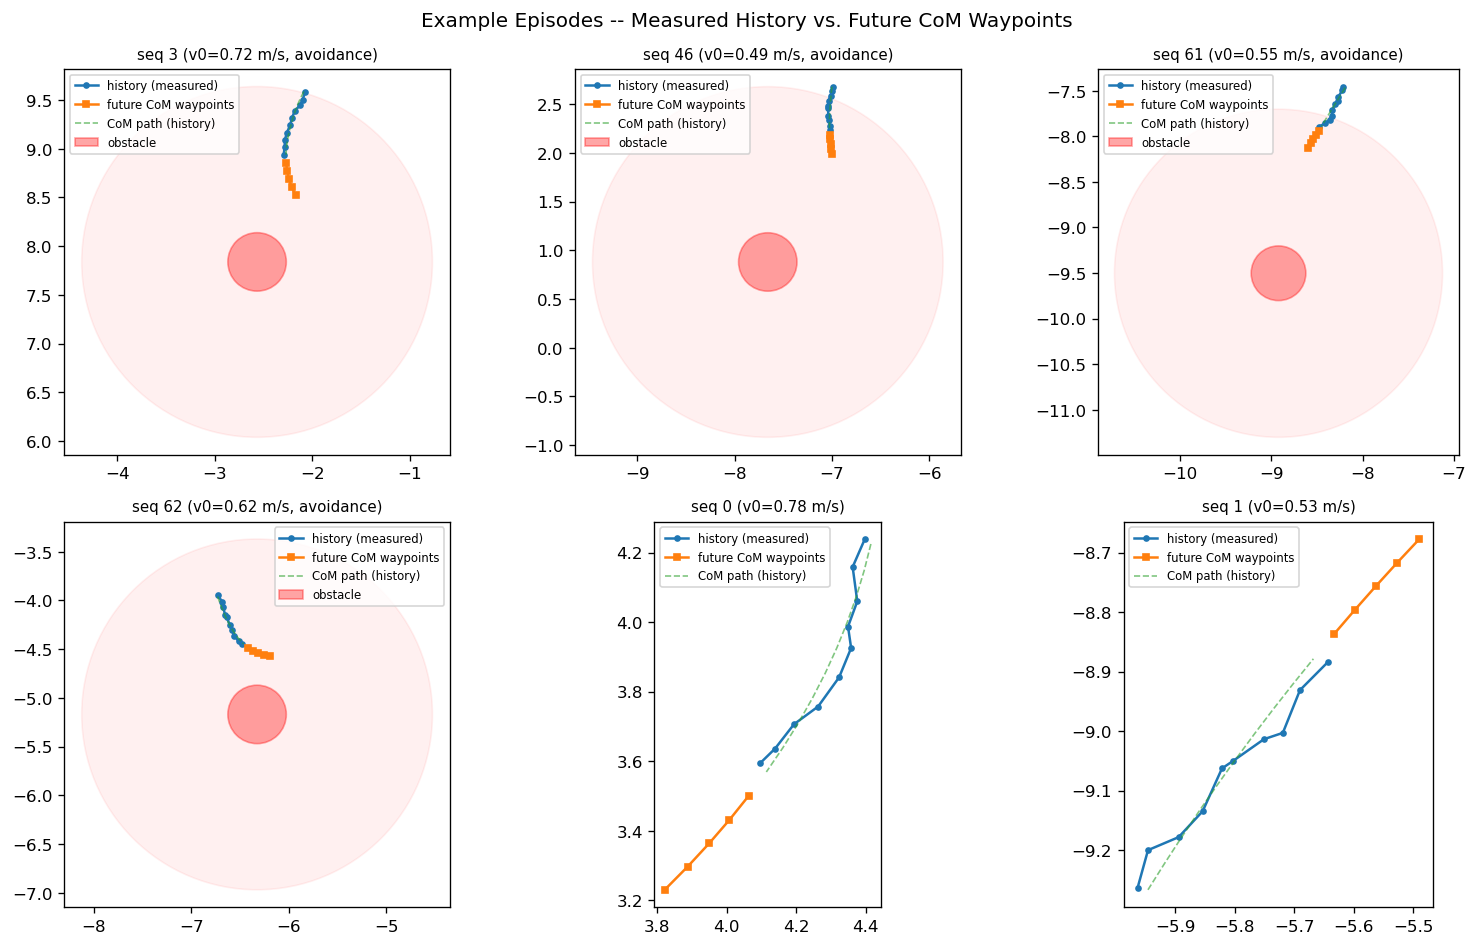

In [3]:
# visual sanity check: 6 test episodes (prefer avoidance-active ones for visibility)
cand = np.where((split == 'test') & avoid_active)[0][:4].tolist() + \
       np.where((split == 'test') & ~has_obs)[0][:2].tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, si in zip(axes.ravel(), cand):
    ax.plot(P_meas[si, :N_HIST, 0], P_meas[si, :N_HIST, 1], 'o-', ms=3, label='history (measured)')
    ax.plot(P[si, N_HIST:, 0], P[si, N_HIST:, 1], 's-', ms=4, label='future CoM waypoints')
    ax.plot(P[si, :N_HIST, 0], P[si, :N_HIST, 1], '--', lw=1, alpha=0.6, label='CoM path (history)')
    if has_obs[si]:
        ax.add_patch(plt.Circle(obs_pos[si], R_OBS, color='red', alpha=0.35, label='obstacle'))
        ax.add_patch(plt.Circle(obs_pos[si], R_INFL + R_OBS, color='red', alpha=0.06))
    ax.set_title(f'seq {si} (v0={speed0[si]:.2f} m/s'
                 f'{", avoidance" if avoid_active[si] else ", obstacle passive" if has_obs[si] else ""})',
                 fontsize=9)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
plt.suptitle('Example Episodes -- Measured History vs. Future CoM Waypoints')
plt.tight_layout()
plt.savefig(IMG_DIR / 'example_trajectories.png')
plt.show()

## 1.2 Feature/Target Tensors + Split

Inputs: the 10 history steps' 8 measured features, positions re-expressed relative to the last history
pose and headings unwrapped per episode (removes the ±π seam without adding a 9th feature);
standardization fit on train only. Targets: the 5 future CoM waypoints relative to the same last
measured pose, in metres (unscaled, so every reported error is directly in metres).

In [4]:
def build_xy(idx):
    Xp = P_meas[idx][:, :N_HIST].copy()                     # (n, 10, 2) measured positions
    Xp -= Xp[:, -1:, :]                                     # relative to last measured pose
    hd = np.unwrap(heading_meas[idx][:, :N_HIST], axis=1)   # per-episode continuous heading
    X = np.concatenate([Xp, V_meas[idx][:, :N_HIST],
                        hd[..., None],
                        d_left[idx][:, :N_HIST, None],
                        d_center[idx][:, :N_HIST, None],
                        d_right[idx][:, :N_HIST, None]], axis=2)      # (n, 10, 8)
    Y = P[idx][:, N_HIST:] - P_meas[idx][:, N_HIST - 1:N_HIST]        # (n, 5, 2), metres
    return X.astype(np.float32), Y.astype(np.float32)

idx_split = {s: np.where(split == s)[0] for s in ['train', 'val', 'test']}
X_raw, Y = {}, {}
for s, idx in idx_split.items():
    X_raw[s], Y[s] = build_xy(idx)

FEAT_NAMES = ['rel_x', 'rel_y', 'vx', 'vy', 'heading', 'd_left', 'd_center', 'd_right']
f_mean = X_raw['train'].reshape(-1, 8).mean(0)
f_std = X_raw['train'].reshape(-1, 8).std(0) + 1e-8
X = {s: ((X_raw[s] - f_mean) / f_std).astype(np.float32) for s in X_raw}

for s in ['train', 'val', 'test']:
    print(f'{s:5s}: X={X[s].shape}  Y={Y[s].shape}  ({len(idx_split[s])/N_SEQ*100:.0f}%)')
print(f'Mean |target| per horizon (m): '
      + '  '.join(f'h{h+1}={np.linalg.norm(Y["train"][:, h], axis=1).mean():.3f}' for h in range(N_FUT)))

train: X=(3500, 10, 8)  Y=(3500, 5, 2)  (70%)
val  : X=(750, 10, 8)  Y=(750, 5, 2)  (15%)
test : X=(750, 10, 8)  Y=(750, 5, 2)  (15%)
Mean |target| per horizon (m): h1=0.064  h2=0.124  h3=0.185  h4=0.247  h5=0.310


## 2. Shared Training Protocol

W03 regime unchanged: Adam(lr=1e-3), batch 128, ≤100 epochs, early stopping on val MSE (patience 10, best checkpoint restored); loss = MSE over the 10 output coordinates. Neural models trained on **5 seeds** (42–46); Linear is closed-form. **CV extrapolation** (last measured velocity carried forward) is the zero-parameter physics floor every learned model must beat.

In [5]:
def train_regressor(model, X_tr, Y_tr, X_va, Y_va, device, max_epochs=100, patience=10,
                    weight_decay=0.0):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr)),
                        batch_size=128, shuffle=True)
    Xtr_t, Ytr_t = torch.tensor(X_tr, device=device), torch.tensor(Y_tr, device=device)
    Xva_t, Yva_t = torch.tensor(X_va, device=device), torch.tensor(Y_va, device=device)
    best_val, best_state, best_epoch, n_bad = np.inf, None, -1, 0
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            tr_loss = criterion(model(Xtr_t), Ytr_t).item()
            va_loss = criterion(model(Xva_t), Yva_t).item()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        if va_loss < best_val - 1e-7:
            best_val, best_epoch, n_bad = va_loss, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            n_bad += 1
            if n_bad >= patience:
                break
    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return model, history


def euclid_per_horizon(Y_true, Y_pred):
    d = np.linalg.norm(Y_pred - Y_true, axis=2)   # (n, 5) metres
    return d.mean(axis=0), d.mean()


def predict_torch(model, Xs, device):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xs, device=device)).cpu().numpy()


def measure_latency_ms(fn, n_reps=200):
    fn()   # warm-up
    return timeit.timeit(fn, number=n_reps) / n_reps * 1000


# constant-velocity floor: last measured velocity carried forward from the last measured pose
def cv_predict(idx):
    v_last = V_meas[idx][:, N_HIST - 1]                       # (n, 2)
    steps = (np.arange(1, N_FUT + 1) * DT)[None, :, None]     # (1, 5, 1)
    return v_last[:, None, :] * steps

print('Protocol helpers defined.')

Protocol helpers defined.


## 3. Models

One line each (full justification: report §3): **Linear** — flattened 80-D → 10 outputs, closed form; the bar for all linear structure. **MLP** — 80→128→64→10, ReLU, dropout 0.1 (regression: heavy dropout inflates metric outputs). **LSTM** — hidden 64 (capacity-matched to W03), final state → all 5 waypoints jointly (an autoregressive decoder adds exposure bias, no capacity gain at this horizon). **Transformer seq2seq** — 2-layer/4-head encoder (d_model 64, W03 scale) + **5 learned horizon queries** cross-attending over the encoded history, making per-waypoint attention directly readable (§6).

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class MLPRegressor(nn.Module):
    def __init__(self, n_hist=10, n_feat=8, n_fut=5, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_hist * n_feat, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_fut * 2))
        self.n_fut = n_fut

    def forward(self, x):
        return self.net(x).view(-1, self.n_fut, 2)


class LSTMRegressor(nn.Module):
    def __init__(self, n_feat=8, hidden=64, n_fut=5):
        super().__init__()
        self.rnn = nn.LSTM(n_feat, hidden, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(hidden, n_fut * 2)
        self.n_fut = n_fut

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(self.dropout(out[:, -1, :])).view(-1, self.n_fut, 2)


class TrajTransformer(nn.Module):
    def __init__(self, n_feat=8, d_model=64, nhead=4, num_layers=2, dim_feedforward=128,
                 dropout=0.1, n_hist=10, n_fut=5):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=n_hist)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                           dim_feedforward=dim_feedforward, dropout=dropout,
                                           batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.horizon_query = nn.Parameter(torch.randn(n_fut, d_model) * 0.02)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 2)

    def forward(self, x, return_attn=False):
        mem = self.encoder(self.pos_enc(self.input_proj(x)))
        q = self.horizon_query.unsqueeze(0).expand(x.size(0), -1, -1)
        ctx, attn = self.cross_attn(q, mem, mem, need_weights=True)   # attn: (B, 5, 10), head-avg
        out = self.head(self.norm(ctx))
        if return_attn:
            return out, attn
        return out


MODEL_FACTORY = {'MLP': MLPRegressor, 'LSTM': LSTMRegressor, 'Transformer': TrajTransformer}
for name, cls in MODEL_FACTORY.items():
    n = sum(p.numel() for p in cls().parameters())
    print(f'{name:12s}: {n:,} parameters')

MLP         : 19,274 parameters
LSTM        : 19,594 parameters
Transformer : 84,738 parameters


## 4. Canonical-Seed Training (seed 42) — Learning Curves

MLP         : 64 epochs, best epoch 54, best val MSE=0.000185


LSTM        : 69 epochs, best epoch 59, best val MSE=0.000151


Transformer : 57 epochs, best epoch 47, best val MSE=0.000212


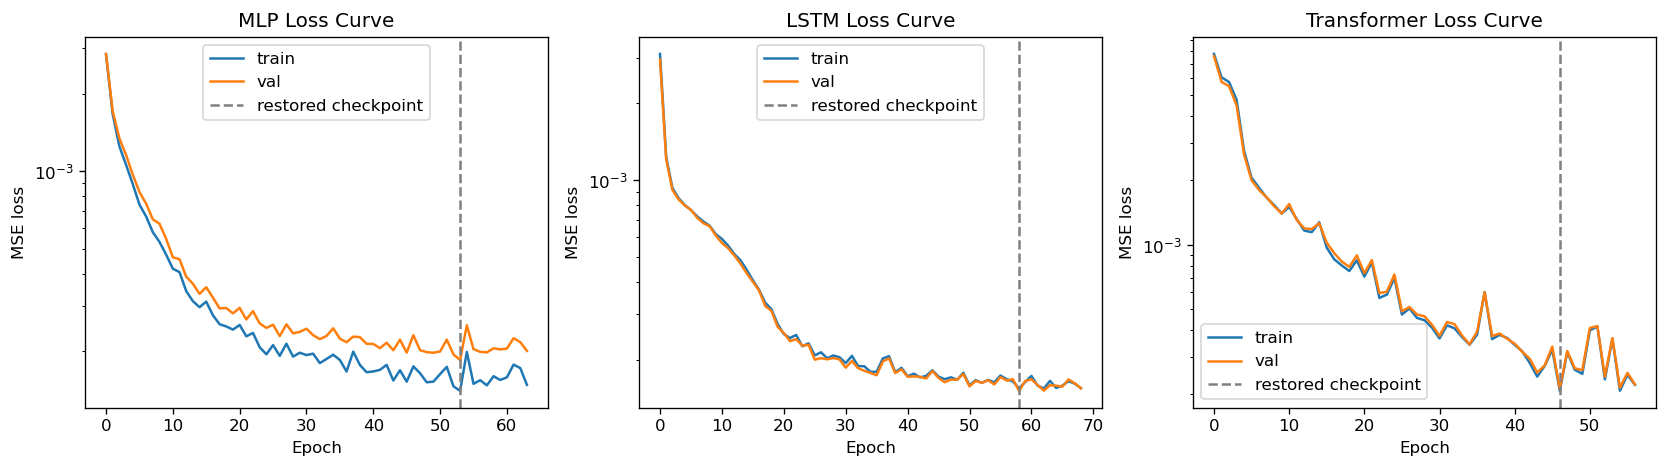

In [7]:
canon_models, canon_histories = {}, {}
for name, cls in MODEL_FACTORY.items():
    torch.manual_seed(SEED)
    model, hist = train_regressor(cls(), X['train'], Y['train'], X['val'], Y['val'], DEVICE)
    canon_models[name], canon_histories[name] = model, hist
    print(f'{name:12s}: {len(hist["train_loss"])} epochs, best epoch {hist["best_epoch"] + 1}, '
          f'best val MSE={hist["val_loss"][hist["best_epoch"]]:.6f}')

linreg = LinearRegression().fit(X['train'].reshape(len(X['train']), -1),
                                Y['train'].reshape(len(Y['train']), -1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, hist) in zip(axes, canon_histories.items()):
    ax.plot(hist['train_loss'], label='train')
    ax.plot(hist['val_loss'], label='val')
    ax.axvline(hist['best_epoch'], color='gray', linestyle='--', label='restored checkpoint')
    ax.set(xlabel='Epoch', ylabel='MSE loss', title=f'{name} Loss Curve', yscale='log')
    ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'learning_curves.png')
plt.show()

### 4.1 MLP Regularisation Check

The MLP is the only model whose train/val curves separate. Controlled check with everything else fixed:
dropout 0.1→0.3 and Adam weight decay 1e-4/1e-3, 5 seeds each, selected on val MSE. Adoption decision and
analysis: report §3.1.

In [8]:
mlp_ablation_cfgs = [
    ('baseline (drop 0.1, wd 0)', 0.1, 0.0),
    ('dropout 0.3', 0.3, 0.0),
    ('wd 1e-4 (drop 0.1)', 0.1, 1e-4),
    ('wd 1e-3 (drop 0.1)', 0.1, 1e-3),
]
abl_rows = []
for name, drop, wd in mlp_ablation_cfgs:
    vals, tests, gaps = [], [], []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model, hist = train_regressor(MLPRegressor(dropout=drop), X['train'], Y['train'],
                                      X['val'], Y['val'], DEVICE, weight_decay=wd)
        be = hist['best_epoch']
        vals.append(hist['val_loss'][be])
        gaps.append(hist['val_loss'][be] - hist['train_loss'][be])
        _, overall = euclid_per_horizon(Y['test'], predict_torch(model, X['test'], DEVICE))
        tests.append(overall)
    vals, tests, gaps = np.array(vals), np.array(tests), np.array(gaps)
    abl_rows.append({'config': name,
                     'val_mse_x1e4': f'{vals.mean()*1e4:.2f} +/- {vals.std()*1e4:.2f}',
                     'val_minus_train_x1e4': f'{gaps.mean()*1e4:.2f}',
                     'test_euclid_cm': f'{tests.mean()*100:.2f} +/- {tests.std()*100:.2f}'})
print(pd.DataFrame(abl_rows).to_string(index=False))

                   config  val_mse_x1e4 val_minus_train_x1e4 test_euclid_cm
baseline (drop 0.1, wd 0) 1.93 +/- 0.11                 0.47  1.63 +/- 0.06
              dropout 0.3 2.42 +/- 0.07                 0.32  1.87 +/- 0.04
       wd 1e-4 (drop 0.1) 2.24 +/- 0.07                 0.13  1.79 +/- 0.02
       wd 1e-3 (drop 0.1) 7.40 +/- 0.25                -0.02  3.16 +/- 0.03


## 5. Evaluation — Mean Euclidean + Per-Horizon Error (5 Seeds)

In [9]:
per_seed = {name: {'overall': [], 'horizon': []} for name in MODEL_FACTORY}
for seed in SEEDS:
    for name, cls in MODEL_FACTORY.items():
        if seed == SEED:
            model = canon_models[name]
        else:
            torch.manual_seed(seed)
            model, _ = train_regressor(cls(), X['train'], Y['train'], X['val'], Y['val'], DEVICE)
        hor, overall = euclid_per_horizon(Y['test'], predict_torch(model, X['test'], DEVICE))
        per_seed[name]['overall'].append(overall)
        per_seed[name]['horizon'].append(hor)
        print(f'seed={seed}  [{name:12s}] test mean Euclid={overall*100:.2f} cm')

pred_lin = linreg.predict(X['test'].reshape(len(X['test']), -1)).reshape(-1, N_FUT, 2)
hor_lin, overall_lin = euclid_per_horizon(Y['test'], pred_lin)
pred_cv = cv_predict(idx_split['test'])
hor_cv, overall_cv = euclid_per_horizon(Y['test'], pred_cv)

rows = [{'model': 'CV extrapolation', 'mean_euclid_cm': overall_cv * 100, 'std_cm': 0.0,
         **{f'h{h+1}_cm': hor_cv[h] * 100 for h in range(N_FUT)}},
        {'model': 'Linear', 'mean_euclid_cm': overall_lin * 100, 'std_cm': 0.0,
         **{f'h{h+1}_cm': hor_lin[h] * 100 for h in range(N_FUT)}}]
for name in MODEL_FACTORY:
    ov = np.array(per_seed[name]['overall'])
    hors = np.stack(per_seed[name]['horizon'])
    rows.append({'model': name, 'mean_euclid_cm': ov.mean() * 100, 'std_cm': ov.std() * 100,
                 **{f'h{h+1}_cm': hors[:, h].mean() * 100 for h in range(N_FUT)}})
results_df = pd.DataFrame(rows).round(3)
print()
print(results_df.to_string(index=False))
print('\n(CV and Linear are deterministic -- std over training seeds applies to the neural models only.)')

seed=42  [MLP         ] test mean Euclid=1.61 cm
seed=42  [LSTM        ] test mean Euclid=1.45 cm
seed=42  [Transformer ] test mean Euclid=1.79 cm


seed=43  [MLP         ] test mean Euclid=1.69 cm


seed=43  [LSTM        ] test mean Euclid=1.41 cm


seed=43  [Transformer ] test mean Euclid=1.39 cm


seed=44  [MLP         ] test mean Euclid=1.65 cm


...

seed=45  [LSTM        ] test mean Euclid=1.39 cm


seed=45  [Transformer ] test mean Euclid=1.58 cm


seed=46  [MLP         ] test mean Euclid=1.70 cm


seed=46  [LSTM        ] test mean Euclid=1.52 cm


seed=46  [Transformer ] test mean Euclid=1.50 cm

           model  mean_euclid_cm  std_cm  h1_cm  h2_cm  h3_cm  h4_cm  h5_cm
CV extrapolation           2.768   0.000  1.839  2.030  2.474  3.224  4.275
          Linear           1.504   0.000  0.725  0.979  1.366  1.891  2.562
             MLP           1.634   0.063  1.117  1.216  1.496  1.911  2.428
            LSTM           1.442   0.044  0.951  1.075  1.322  1.686  2.176
     Transformer           1.604   0.151  1.165  1.243  1.468  1.825  2.320

(CV and Linear are deterministic -- std over training seeds applies to the neural models only.)


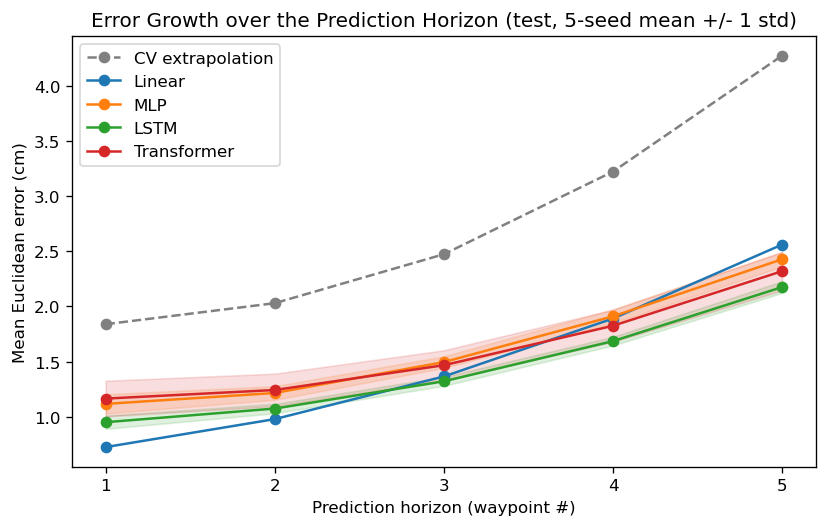

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, 6), hor_cv * 100, marker='o', linestyle='--', color='gray', label='CV extrapolation')
ax.plot(range(1, 6), hor_lin * 100, marker='o', label='Linear')
for name in MODEL_FACTORY:
    hors = np.stack(per_seed[name]['horizon']) * 100
    m, s = hors.mean(0), hors.std(0)
    line, = ax.plot(range(1, 6), m, marker='o', label=name)
    ax.fill_between(range(1, 6), m - s, m + s, alpha=0.15, color=line.get_color())
ax.set(xlabel='Prediction horizon (waypoint #)', ylabel='Mean Euclidean error (cm)',
       title='Error Growth over the Prediction Horizon (test, 5-seed mean +/- 1 std)',
       xticks=range(1, 6))
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'per_horizon_error.png')
plt.show()

### 5.2 Where Does Learning Beat Physics? — Avoidance vs. Obstacle-Free Episodes

The CV floor is exact for straight constant-speed motion; the learnable structure lives in curvature, sway filtering and avoidance steering. Splitting test error by whether avoidance was active isolates how much of each model's gain is manoeuvre anticipation.

In [11]:
test_idx = idx_split['test']
grp = avoid_active[test_idx]
print(f'Test episodes: {len(test_idx)}  (avoidance-active: {grp.sum()}, clean: {(~grp).sum()})')

pred_by_model = {'CV extrapolation': pred_cv, 'Linear': pred_lin}
for name in MODEL_FACTORY:
    pred_by_model[name] = predict_torch(canon_models[name], X['test'], DEVICE)

rows = []
for name, pred in pred_by_model.items():
    d = np.linalg.norm(pred - Y['test'], axis=2)
    rows.append({'model': name,
                 'avoidance_mean_cm': d[grp].mean() * 100,
                 'avoidance_h5_cm': d[grp][:, -1].mean() * 100,
                 'clean_mean_cm': d[~grp].mean() * 100,
                 'clean_h5_cm': d[~grp][:, -1].mean() * 100})
print(pd.DataFrame(rows).round(2).to_string(index=False))

Test episodes: 750  (avoidance-active: 273, clean: 477)


           model  avoidance_mean_cm  avoidance_h5_cm  clean_mean_cm  clean_h5_cm
CV extrapolation               3.50             6.07           2.35         3.25
          Linear               1.91             3.52           1.27         2.01
             MLP               2.14             3.48           1.31         1.82
            LSTM               1.73             2.86           1.29         1.86
     Transformer               2.09             3.16           1.62         2.09


### 5.3 Capacity Control — Param-Matched Transformer

The §4 table matches **width** (d_model=64), so the Transformer carries 84.7K params against ~20K for the MLP/LSTM. A param-matched **Transformer-S** (d_model=32, ff=64, 21.9K params) tests whether the Transformer's weakness here is the attention architecture or simply over-parameterization on 3,500 short (10-step) sequences — the mirror of the W03 control, where the *same* shrink hurt.

In [14]:
def _pc(m):
    return sum(p.numel() for p in m.parameters())
print(f'Params: Transformer(d=64)={_pc(TrajTransformer(d_model=64, dim_feedforward=128)):,}  '
      f'Transformer-S(d=32)={_pc(TrajTransformer(d_model=32, nhead=4, dim_feedforward=64)):,}  '
      f'LSTM={_pc(LSTMRegressor()):,}')

ts_overall = []
for seed in SEEDS:
    torch.manual_seed(seed)
    m = train_regressor(TrajTransformer(d_model=32, nhead=4, dim_feedforward=64),
                        X['train'], Y['train'], X['val'], Y['val'], DEVICE)
    _, ov = euclid_per_horizon(Y['test'], predict_torch(m, X['test'], DEVICE))
    ts_overall.append(ov * 100)
ts_overall = np.array(ts_overall)
tr64 = np.array(per_seed['Transformer']['overall']) * 100
lstm = np.array(per_seed['LSTM']['overall']) * 100
print(f'Transformer-S (d=32) test mean Euclid: {ts_overall.mean():.2f} +/- {ts_overall.std():.2f} cm (5 seeds)')
print(f'  vs Transformer d=64: {tr64.mean():.2f} +/- {tr64.std():.2f} cm   '
      f'vs LSTM: {lstm.mean():.2f} +/- {lstm.std():.2f} cm')

Params: Transformer(d=64)=84,738  Transformer-S(d=32)=21,890  LSTM=19,594
Transformer-S (d=32) test mean Euclid: 1.52 +/- 0.07 cm (5 seeds)
  vs Transformer d=64: 1.60 +/- 0.15 cm   vs LSTM: 1.44 +/- 0.04 cm


**Reading (full analysis: report §4).** Shrinking the Transformer **halves the seed std** (0.15→0.07 cm) and nudges the mean down (1.60→1.52 cm, within noise) — consistent with the d=64 model being over-parameterized on this data scale, not merely mis-tuned. But even matched it still **trails the LSTM** (1.44), so the conclusion stands: attention buys nothing here. This is the exact inverse of W03, where the same d=32 shrink *cost* 0.07 F1 — capacity paid off there (50-step windows) and is wasted here (10-step sequences).

## 6. Attention over the Horizon — Near vs. Far Waypoints

The (5 × 10) cross-attention matrix reads directly as "which part of the history each waypoint is built from": test-set mean, the largest-manoeuvre avoidance sample, and each horizon's attention centre-of-mass.

Avoidance sample: test episode 587 (seq 3894), CV h5 error=21.1 cm


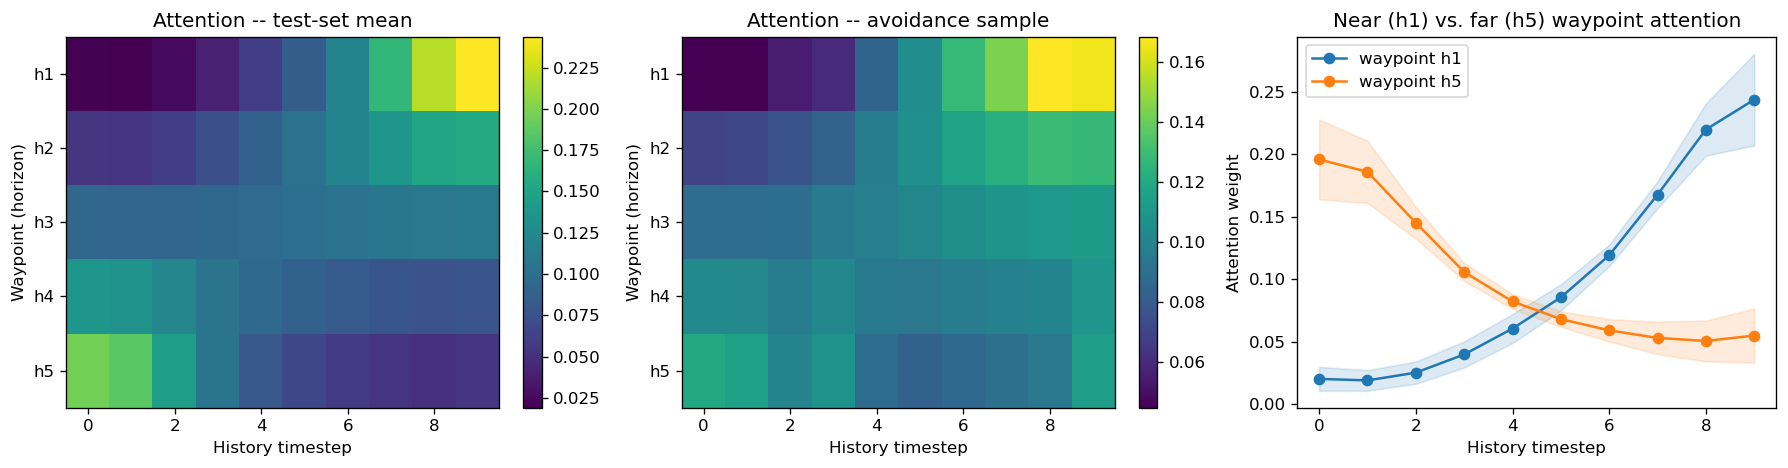

Attention centre-of-mass over history time (step index, test-set mean): h1=6.69  h2=5.57  h3=4.69  h4=3.89  h5=3.09


In [12]:
tr_model = canon_models['Transformer']
tr_model.eval()
with torch.no_grad():
    _, attn_te = tr_model(torch.tensor(X['test'], device=DEVICE), return_attn=True)
attn_te = attn_te.cpu().numpy()          # (n_test, 5, 10)
attn_mean = attn_te.mean(axis=0)

# avoidance episode with the largest CV failure at h5 (most manoeuvre to anticipate)
d_cv_h5 = np.linalg.norm(pred_cv - Y['test'], axis=2)[:, -1]
cand = np.where(grp)[0]
sample_j = cand[np.argmax(d_cv_h5[cand])]
print(f'Avoidance sample: test episode {sample_j} (seq {test_idx[sample_j]}), '
      f'CV h5 error={d_cv_h5[sample_j]*100:.1f} cm')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(attn_mean, aspect='auto', cmap='viridis')
axes[0].set(xlabel='History timestep', ylabel='Waypoint (horizon)', title='Attention -- test-set mean',
            yticks=range(5), yticklabels=[f'h{h+1}' for h in range(5)])
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(attn_te[sample_j], aspect='auto', cmap='viridis')
axes[1].set(xlabel='History timestep', ylabel='Waypoint (horizon)',
            title='Attention -- avoidance sample', yticks=range(5),
            yticklabels=[f'h{h+1}' for h in range(5)])
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for h in [0, 4]:
    m = attn_te[:, h, :].mean(axis=0)
    s = attn_te[:, h, :].std(axis=0)
    line, = axes[2].plot(range(N_HIST), m, marker='o', label=f'waypoint h{h+1}')
    axes[2].fill_between(range(N_HIST), m - s, m + s, alpha=0.15, color=line.get_color())
axes[2].set(xlabel='History timestep', ylabel='Attention weight',
            title='Near (h1) vs. far (h5) waypoint attention')
axes[2].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'attention_over_horizon.png')
plt.show()

com = (attn_mean * np.arange(N_HIST)).sum(axis=1)
print('Attention centre-of-mass over history time (step index, test-set mean): '
      + '  '.join(f'h{h+1}={com[h]:.2f}' for h in range(N_FUT)))

**Attention reading (full analysis: report §5).** The attention centre-of-mass moves monotonically earlier with horizon (h1 ≈ step 6.7 → h5 ≈ step 3.1): near waypoints read the latest state, far waypoints read the older trend/manoeuvre context (including how fast the sector clearance was closing in avoidance episodes) — the learned analogue of a receding-horizon planner weighting instantaneous state near and context far.

## 7. Latency vs. Accuracy — the 50 ms Motion-Planning Gate

Single-sequence CPU inference (deployment shape: one history per planner tick), `timeit` with warm-up; batch column = throughput headroom. Gate: the plan's 50 ms (plan-defined; product docs specify 10 ms MPC / <150 ms grasp instead).

           model  single_ms  batch_ms verdict_50ms
             MLP     0.0326    0.3314         PASS
            LSTM     0.3381    2.6678         PASS
     Transformer     0.5134    7.8278         PASS
          Linear     0.0873       NaN         PASS
CV extrapolation     0.0030       NaN         PASS


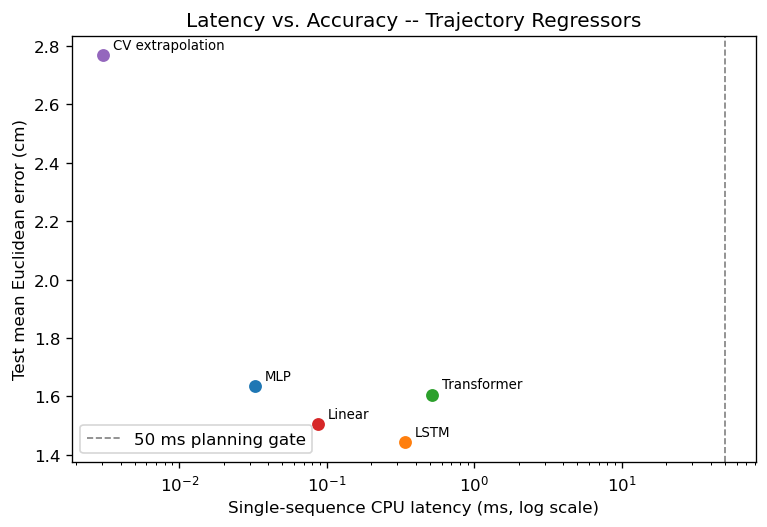


Transformer vs LSTM: error 1.60 vs 1.44 cm, latency 0.513 vs 0.338 ms; MLP error 1.63 cm. Gate headroom: worst single-sequence latency is 0.513 ms against the 50 ms budget.


In [13]:
x_single = torch.tensor(X['test'][:1])
x_batch = torch.tensor(X['test'])   # full test set (750 sequences)
x_lin_single = X['test'][:1].reshape(1, -1)

lat_rows = []
for name in MODEL_FACTORY:
    m_cpu = copy.deepcopy(canon_models[name]).to('cpu').eval()
    with torch.no_grad():
        single = measure_latency_ms(lambda: m_cpu(x_single))
        batch = measure_latency_ms(lambda: m_cpu(x_batch), n_reps=20)
    lat_rows.append({'model': name, 'single_ms': single, 'batch_ms': batch})
lat_rows.append({'model': 'Linear', 'single_ms': measure_latency_ms(lambda: linreg.predict(x_lin_single)),
                 'batch_ms': np.nan})
v_last_te = V_meas[idx_split['test']][:1, N_HIST - 1]
steps_arr = (np.arange(1, N_FUT + 1) * DT)[None, :, None]
lat_rows.append({'model': 'CV extrapolation',
                 'single_ms': measure_latency_ms(lambda: v_last_te[:, None, :] * steps_arr),
                 'batch_ms': np.nan})

lat_df = pd.DataFrame(lat_rows)
lat_df['verdict_50ms'] = np.where(lat_df['single_ms'] <= CONSTRAINT_MS, 'PASS', 'FAIL')
print(lat_df.round(4).to_string(index=False))

err_lookup = {r['model']: r['mean_euclid_cm'] for _, r in results_df.iterrows()}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for _, r in lat_df.iterrows():
    ax.scatter(r['single_ms'], err_lookup[r['model']], s=45)
    ax.annotate(r['model'], (r['single_ms'], err_lookup[r['model']]),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axvline(CONSTRAINT_MS, color='0.5', linestyle='--', linewidth=1, label='50 ms planning gate')
ax.set(xlabel='Single-sequence CPU latency (ms, log scale)', ylabel='Test mean Euclidean error (cm)',
       title='Latency vs. Accuracy -- Trajectory Regressors', xscale='log')
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'latency_vs_error.png')
plt.show()

tr_err = np.array(per_seed['Transformer']['overall']).mean() * 100
lstm_err = np.array(per_seed['LSTM']['overall']).mean() * 100
mlp_err = np.array(per_seed['MLP']['overall']).mean() * 100
tr_lat = lat_df.loc[lat_df.model == 'Transformer', 'single_ms'].iloc[0]
lstm_lat = lat_df.loc[lat_df.model == 'LSTM', 'single_ms'].iloc[0]
print(f'\nTransformer vs LSTM: error {tr_err:.2f} vs {lstm_err:.2f} cm, '
      f'latency {tr_lat:.3f} vs {lstm_lat:.3f} ms; MLP error {mlp_err:.2f} cm. '
      f'Gate headroom: worst single-sequence latency is '
      f'{lat_df.single_ms.max():.3f} ms against the 50 ms budget.')

**Feasibility & tradeoff (full analysis: report §6).** Every regressor clears 50 ms by ≥2 orders of magnitude — latency does not constrain model choice. The Transformer's extra compute buys nothing: slower than the LSTM, less accurate, 3× the seed variance (84.7K params on 3,500 short sequences — the opposite regime from W03's 50-step windows). Transformer-vs-MLP/Linear gaps sit within ~1 seed-std (not significant). Pick: **LSTM**; Linear as the minimal-footprint choice where motion is known obstacle-free.